# Solar System Simulation

This notebook demonstrates the `orbit` Python API to simulate the full solar system and inspect the results.

In [1]:
import orbit
import numpy as np
import matplotlib.pyplot as plt

print('orbit version:', orbit.__version__)

orbit version: 2.0.0-dev


## Run the simulation

Simulate 1 year (365 days) with a 1-hour timestep, recording every step.

In [2]:
SECONDS_PER_HOUR = 3600.0
HOURS_PER_YEAR   = 365 * 24

result = orbit.simulate(
    '../systems/solar_system.json',
    steps=HOURS_PER_YEAR,
    dt=SECONDS_PER_HOUR,
)

print('Bodies:       ', result.body_names)
print('Snapshots:    ', len(result.snapshots))
print('Timestep (s): ', result.dt)

Bodies:        ['Sun', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']
Snapshots:     8760
Timestep (s):  3600.0


## Extract positions

`positions_numpy()` returns a NumPy array of shape `(n_steps, n_bodies, 3)` in metres.

In [3]:
pos = result.positions_numpy()          # (n_steps, n_bodies, 3)  metres
AU  = 1.496e11                          # metres per AU
pos_au = pos / AU

print('Array shape:', pos_au.shape)     # (8760, 10, 3)

Array shape: (8760, 10, 3)


## Plot orbital trajectories (XY plane)

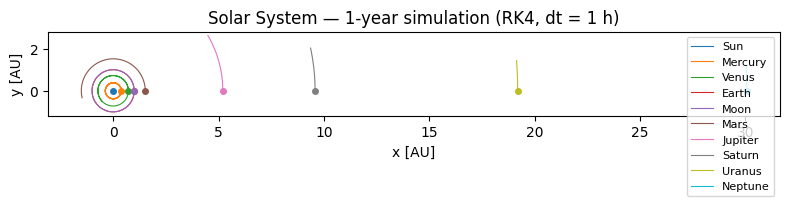

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

for i, name in enumerate(result.body_names):
    x = pos_au[:, i, 0]
    y = pos_au[:, i, 1]
    ax.plot(x, y, lw=0.8, label=name)
    ax.plot(x[0], y[0], 'o', ms=4, color=ax.lines[-1].get_color())

ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Solar System — 1-year simulation (RK4, dt = 1 h)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## Energy conservation

A well-behaved integrator keeps total mechanical energy nearly constant.
The relative drift `(E(t) - E(0)) / |E(0)|` should stay close to machine epsilon.

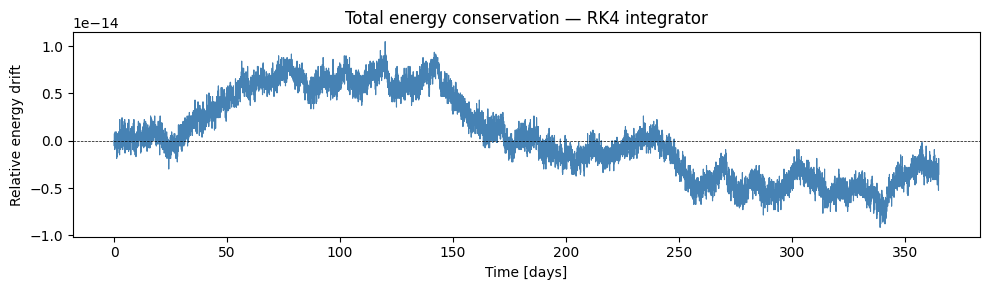

Max |drift|: 1.047e-14


In [5]:
E = result.energies_numpy()             # (n_steps,)  Joules
t = np.arange(len(E)) / 24.0           # hours → days

drift = (E - E[0]) / abs(E[0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, drift, lw=0.8, color='steelblue')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Relative energy drift')
ax.set_title('Total energy conservation — RK4 integrator')
plt.tight_layout()
plt.show()

print(f'Max |drift|: {np.abs(drift).max():.3e}')